# 07 · Motor de decisión, cut-off y rentabilidad — Caso 15 · Caja Rural 360

**Alcance:** sección **6.9**. Narrativa en `reports/09_decision_engine.md`.

La decisión no es el score: es el score **calibrado** (6.7) más capacidad de pago, reglas duras de política (6.1), apetito de riesgo y criterios del producto. El motor devuelve tres salidas —**APPROVE**, **REVIEW**, **REJECT**— con su motivo, el monto recomendado y la tasa recomendada.

**Economía (supuestos explícitos, en `config.py`):**

    margen           = monto x (tasa − costo de fondos 6% − gasto operativo 5%) x factor de saldo 0.55 x plazo/12
    pérdida esperada = PD calibrada x EAD/monto 0.42 x LGD 0.62 x monto
    resultado        = margen − pérdida esperada

EAD y LGD usan por ahora los promedios estables que midió 6.4; **6.10 y 6.11 los reemplazan por modelos** y esta capa no cambia.

**Cómo se evalúa una política.** Sobre **todas las solicitudes** (TTD), no solo las históricamente aprobadas: donde hay resultado observado se usa el observado y donde no (rechazados históricos) se usa la PD calibrada. El umbral se elige con 2024 (VAL) y **2025 (OOT) se usa solo como confirmación**.

| Sección | Contenido |
|---|---|
| 1 | Árbol de decisión y reglas |
| 2 | Curva de trade-off y elección del cut-off |
| 3 | Política recomendada: resultados en 2024 |
| 4 | Swap-in / swap-out contra la política histórica |
| 5 | Pricing por riesgo y asignación de monto |
| 6 | Cumplimiento del Risk Appetite y conflicto crecimiento-riesgo |
| 7 | Confirmación en OOT 2025 y recomendación final |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
import joblib
raw = data.load_raw()
pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
dev, val, oot = (fx[fx["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
cols_in = pipeline.pipeline_input_columns()
pipe = pipeline.build_pipeline().fit(dev[cols_in])
card = sc.Scorecard.load(cfg.ROOT / "models" / "scorecard_pd_v1.json")
(cfg.ROOT / "models").mkdir(exist_ok=True)


challenger = joblib.load(cfg.ROOT / "models" / "challenger_lgbm_v1.joblib")
platt = ev.PlattCalibrator().fit(card.predict_pd(val), val[T])          # calibrador de 6.7
pd_calibrada = lambda d: platt.transform(card.predict_pd(d))
politica = dec.DecisionPolicy()                                          # umbrales de config, elegidos en §2
ttd = {a: features.build_features(raw[raw[cfg.DATE_COL].dt.year == a]) for a in (2024, 2025)}
pd_ttd = {a: pd_calibrada(t) for a, t in ttd.items()}
observado = {a: np.where(t[cfg.OUTCOME_FILTER].eq(1), t[T], np.nan) for a, t in ttd.items()}
esperado = {a: np.where(np.isnan(observado[a]), pd_ttd[a], observado[a]) for a in ttd}


print("Umbrales de política (config):", {"PD aprobación": cfg.PD_APPROVE_MAX, "PD rechazo": cfg.PD_REJECT_MIN,
      "DTI automático": cfg.DTI_POST_AUTO_MAX, "DTI tope": cfg.DTI_POST_HARD_MAX,
      "monto revisión": cfg.MICRO_MAX_AUTO_AMOUNT, "capacidad de revisión": cfg.REVIEW_CAPACITY})
print("Supuestos económicos:", {"fondeo": cfg.COST_OF_FUNDS, "gasto operativo": cfg.OPERATING_COST_RATE,
      "factor de saldo": cfg.AVG_BALANCE_FACTOR, "EAD/monto": cfg.EAD_FACTOR_BASELINE, "LGD": cfg.LGD_BASELINE,
      "margen objetivo": cfg.TARGET_MARGIN})
for a in ttd:
    print(f"TTD {a}: {len(ttd[a]):,} solicitudes | aprobación histórica {ttd[a][cfg.APPROVED_FLAG].mean():.1%}"
          f" | default de los aprobados {ttd[a].loc[ttd[a][cfg.OUTCOME_FILTER].eq(1), T].mean():.1%}")

Umbrales de política (config): {'PD aprobación': 0.18, 'PD rechazo': 0.2, 'DTI automático': 0.45, 'DTI tope': 0.6, 'monto revisión': 20000, 'capacidad de revisión': 0.2}
Supuestos económicos: {'fondeo': 0.06, 'gasto operativo': 0.05, 'factor de saldo': 0.55, 'EAD/monto': 0.415, 'LGD': 0.616, 'margen objetivo': 0.05}
TTD 2024: 1,389 solicitudes | aprobación histórica 82.9% | default de los aprobados 14.0%
TTD 2025: 1,457 solicitudes | aprobación histórica 81.6% | default de los aprobados 13.4%


## 1. Árbol de decisión

El orden importa, porque una solicitud puede caer en más de una regla:

1. **REVIEW cuando falta información**: sin score de buró (re-consultar) o sin ingreso declarado (verificar en campo). Van **antes** del rechazo a propósito: si el insumo principal del modelo está imputado, la PD no es confiable y no corresponde rechazar en automático. Es lo que fija la política de 6.1 y lo que sostiene el análisis de fairness de 6.8.
2. **REJECT** si la PD calibrada supera el umbral de rechazo: aquí el modelo sí tiene toda su información y el riesgo está fuera del apetito aun con contraoferta.
3. **REVIEW por verificación**, cuando el dato existe pero hay que sustentarlo: monto sobre S/ 20,000 (6.4 mostró que ese tramo es errático y concentra exposición) y efectivo sobre 80% con ticket sobre S/ 10,000 (verificación de ingreso, no penalidad).
4. **Contraoferta automática de monto**: si el monto pedido excede la capacidad, el motor calcula el máximo que deja el DTI post-crédito en 45% y **recalcula la PD con ese monto**. Exceder el DTI no manda a analista: dispara una contraoferta.
5. Si ni con la contraoferta hay un monto comercial (menos de S/ 1,000), va a **REVIEW** cuando el riesgo es bajo (evaluar plazo mayor o consolidación) y a **REJECT** cuando además la PD está fuera del tramo automático. A quien va a analista por capacidad se le calcula el techo del **60% de DTI post-crédito**, que es hasta donde la política permite llegar con validación: el analista recibe un monto concreto, no un "no".
6. **REVIEW** en la zona gris de PD; **APPROVE** en el resto.

**Trazabilidad con los disparadores de revisión de 6.1 §8.** Los cuatro primeros se implementan tal cual. El quinto, distancia mayor a 50 km, **no se implementa**: 6.4 mostró que ese segmento no tiene peor default ni peor LGD, y que el costo de recuperación tampoco crece con la distancia (Spearman 0.03, p = 0.48). Mantenerlo habría gastado capacidad de análisis en un grupo sin evidencia de riesgo y habría penalizado justo a la población que el caso quiere incluir.

## 2. Curva de trade-off y elección del cut-off

In [3]:
t24, p24, esp24 = ttd[2024], pd_ttd[2024], esperado[2024]
filas = []
for umbral in np.round(np.arange(0.08, 0.31, 0.01), 3):
    for rechazo in [umbral + 0.02, 0.25]:
        pol = dec.DecisionPolicy(pd_approve_max=float(umbral), pd_reject_min=float(round(rechazo, 3)))
        d = pol.decide(t24, p24, recalcular_pd=pd_calibrada)
        r = dec.policy_summary(t24, d, p24, default_esperado=esp24)
        filas.append({"pd_aprobacion": umbral, "pd_rechazo": round(rechazo, 3), "aprobacion_auto": r["aprobacion"],
                      "revision": r["revision"], "rechazo_pct": r["rechazo"],
                      "aprobacion_final": r["aprobacion_final_esperada"], "default_auto": r["default_esperado"],
                      "default_cartera_final": r["default_cartera_final"], "el_cartera_final": r["el_cartera_final"],
                      "resultado_cartera_final": r["resultado_cartera_final"]})
curva = pd.DataFrame(filas)
curva.to_csv(cfg.TABLES / "decision_curva_tradeoff.csv", index=False)
estrecha = curva[np.isclose(curva.pd_rechazo, curva.pd_aprobacion + 0.02)].set_index("pd_aprobacion")
display(estrecha.round(4))

,pd_rechazo,aprobacion_auto,revision,rechazo_pct,aprobacion_final,default_auto,default_cartera_final,el_cartera_final,resultado_cartera_final
pd_aprobacion,,,,,,,,,
0.0800,0.1000,0.1389,0.2131,0.6479,0.2668,0.0615,0.0729,0.0174,0.0870
0.0900,0.1100,0.2095,0.2419,0.5486,0.3546,0.0714,0.0748,0.0184,0.0861
0.1000,0.1200,0.2635,0.2203,0.5162,0.3957,0.0728,0.0744,0.0185,0.0856
0.1100,0.1300,0.3405,0.1872,0.4723,0.4528,0.0759,0.0789,0.0206,0.0838
0.1200,0.1400,0.3701,0.1908,0.4392,0.4845,0.0749,0.0797,0.0214,0.0831
0.1300,0.1500,0.4039,0.2037,0.3924,0.5261,0.0794,0.0835,0.0227,0.0803
0.1400,0.1600,0.4269,0.1951,0.3780,0.5440,0.0832,0.0877,0.0242,0.0786
0.1500,0.1700,0.4629,0.2239,0.3132,0.5973,0.0858,0.0948,0.0259,0.0779
0.1600,0.1800,0.4694,0.2469,0.2837,0.6176,0.0893,0.0995,0.0271,0.0765


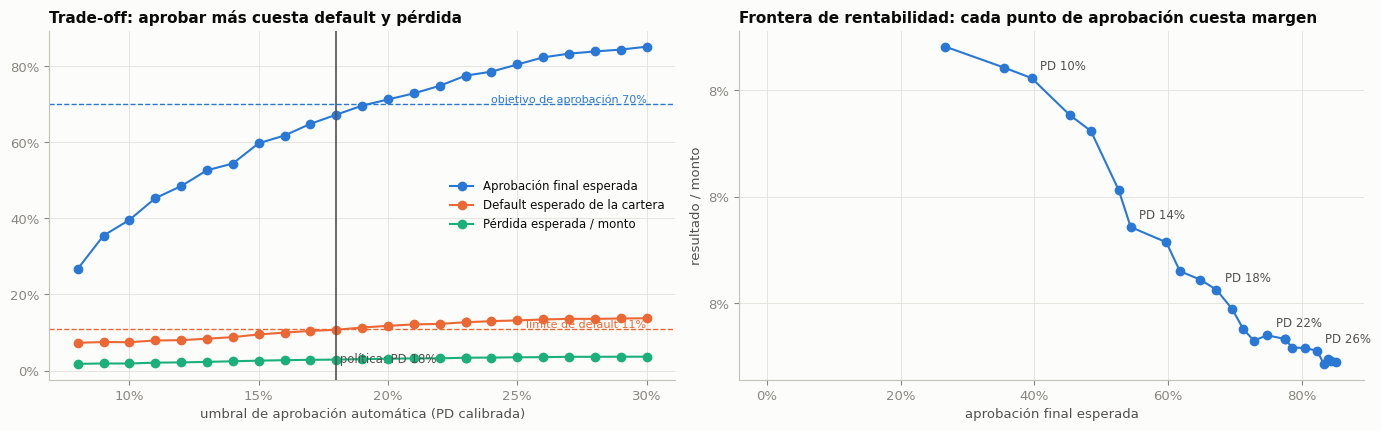

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
ax = axes[0]
ax.plot(estrecha.index, estrecha["aprobacion_final"], marker="o", color=BLUE, label="Aprobación final esperada")
ax.plot(estrecha.index, estrecha["default_cartera_final"], marker="o", color=ORANGE, label="Default esperado de la cartera")
ax.plot(estrecha.index, estrecha["el_cartera_final"], marker="o", color=AQUA, label="Pérdida esperada / monto")
ax.axhline(0.11, color=ORANGE, lw=1, ls="--"); ax.text(0.30, 0.112, "límite de default 11%", color=ORANGE, fontsize=8, ha="right")
ax.axhline(0.70, color=BLUE, lw=1, ls="--"); ax.text(0.30, 0.705, "objetivo de aprobación 70%", color=BLUE, fontsize=8, ha="right")
ax.axvline(cfg.PD_APPROVE_MAX, color=INK_2, lw=1.2)
ax.text(cfg.PD_APPROVE_MAX, 0.02, f" política: PD {cfg.PD_APPROVE_MAX:.0%}", color=INK_2, fontsize=8.5)
ax.set_xlabel("umbral de aprobación automática (PD calibrada)"); pct_axis(ax); pct_axis(ax, axis="x")
ax.set_title("Trade-off: aprobar más cuesta default y pérdida"); ax.legend(loc="center right", fontsize=8.5)
ax = axes[1]
ax.plot(estrecha["aprobacion_final"], estrecha["resultado_cartera_final"], marker="o", color=BLUE)
for u in [0.10, 0.14, 0.18, 0.22, 0.26]:
    if u in estrecha.index:
        ax.annotate(f"PD {u:.0%}", (estrecha.loc[u, "aprobacion_final"], estrecha.loc[u, "resultado_cartera_final"]),
                    xytext=(6, 6), textcoords="offset points", fontsize=8.5, color=INK_2)
ax.axvspan(0, cfg.REVIEW_CAPACITY + 0.5, alpha=0)  # marcador visual neutro
ax.set_xlabel("aprobación final esperada"); ax.set_ylabel("resultado / monto")
pct_axis(ax); pct_axis(ax, axis="x")
ax.set_title("Frontera de rentabilidad: cada punto de aprobación cuesta margen")
fig.tight_layout(); savefig(fig, "fig27_tradeoff"); plt.show()

**Cómo se eligió el cut-off.** Tres restricciones, en este orden:

1. **Default de la cartera final ≤ 11%** y **pérdida esperada ≤ 3%** (límites de riesgo del apetito, 6.1).
2. **Revisión manual ≤ 20% de las solicitudes**, que es la capacidad declarada de los analistas.
3. Maximizar aprobación y resultado dentro de lo anterior.

Con PD de aprobación en **18%** y rechazo en **20%**: aprobación automática 53.3%, revisión 23.2%, rechazo 23.5%, default esperado de la cartera final 10.7% y pérdida esperada 2.9%. Subir el umbral a 20% lleva el default a 11.7% y rompe el límite; bajarlo a 15% lo baja a 9.5% pero cuesta 7.5 puntos de aprobación final.

La zona gris quedó estrecha a propósito (18% a 20%): con la capacidad de revisión de 20%, casi todo el cupo lo consumen las reglas duras, que son las que un analista puede efectivamente resolver (re-consultar buró, verificar ingreso, validar un ticket grande). Ampliar la zona gris sin ampliar la capacidad solo generaría una cola.

## 3. Política recomendada: resultados en 2024

In [5]:
politica = dec.DecisionPolicy()
d24 = politica.decide(t24, p24, recalcular_pd=pd_calibrada)
resumen24 = dec.policy_summary(t24, d24, p24, default_esperado=esp24)
display(pd.Series(resumen24).to_frame("2024").T)
print("\nMezcla de decisiones y motivos:")
display(d24.groupby(["decision", "motivo"]).size().to_frame("solicitudes").assign(
    pct=lambda x: x["solicitudes"] / len(d24)).sort_values("solicitudes", ascending=False))
print(f"Contraofertas de monto: {d24.contraoferta.mean():.1%} de las solicitudes | "
      f"monto ofrecido / solicitado en aprobados: {resumen24['monto_recomendado_sobre_solicitado']:.2f}")
d24.to_csv(cfg.TABLES / "decision_detalle_2024.csv", index=False)

,aprobacion,default_esperado,el_sobre_monto,margen_sobre_monto,resultado_sobre_monto,creditos,aprobacion_final_esperada,default_cartera_final,el_cartera_final,resultado_cartera_final,revision,rechazo,tasa_media_recomendada,monto_recomendado_sobre_solicitado
2024,0.5328,0.0995,0.0255,0.1027,0.0773,740.0000,0.6723,0.1070,0.0286,0.0756,0.2325,0.2347,0.2004,0.8955



Mezcla de decisiones y motivos:


solicitudes    pct
decision motivo                                                                
APPROVE  Riesgo y capacidad dentro del apetito                       570 0.4104
REJECT   PD calibrada >= 20%                                         325 0.2340
APPROVE  Aprobado con contraoferta de monto por capacida...          170 0.1224
REVIEW   Capacidad de pago insuficiente: evaluar plazo m...          145 0.1044
         Sin score de buró: re-consultar y verificar ide...           45 0.0324
         Monto > S/ 20,000: revisión obligatoria                      37 0.0266
         PD calibrada entre 18% y 20%                                 34 0.0245
         Ingreso mayormente en efectivo con ticket alto:...           33 0.0238
         Sin ingreso declarado: verificar capacidad de p...           29 0.0209
REJECT   Capacidad de pago insuficiente y PD fuera del t...            1 0.0007

Contraofertas de monto: 40.1% de las solicitudes | monto ofrecido / solicitado en aprobados: 0.90


**Lectura.** Poco más de la mitad de las solicitudes se resuelve sola, 23.5% se rechaza por riesgo y 23.2% va a analista, principalmente por reglas verificables (buró sin score, ingreso no declarado, ticket alto, efectivo alto) y no por dudas del modelo. El motor contraoferta monto en el 12% de los casos y, en los aprobados, ofrece en promedio **90% del monto pedido**: es el mecanismo que permite decir que sí con menos exposición en vez de decir que no.

## 4. Swap-in / swap-out contra la política histórica

In [6]:
swap = dec.swap_analysis(t24, d24, t24[cfg.APPROVED_FLAG])
display(swap)
swap.to_csv(cfg.TABLES / "decision_swap_2024.csv")

,solicitudes,monto,default_observado,pct_solicitudes
grupo,,,,
Se mantienen aprobados,652,"4,461,546.6600",0.0982,0.4694
Se mantienen fuera,150,"1,360,594.2100",NaN,0.1080
Swap-in: entran,88,"626,299.1300",NaN,0.0634
Swap-out: salen,499,"4,696,152.0200",0.1944,0.3593


**Lectura.** El swap-out —solicitudes que la Caja aprobó y esta política no aprueba automáticamente— tenía **19.4% de default observado**, el doble que las que se mantienen aprobadas (9.8%). Es la mejor evidencia de que el modelo no está recortando al azar: saca justo la parte de la cartera que explicaba la pérdida. En paralelo entra un 6.3% de solicitudes que la política histórica rechazaba y que ahora califican, en línea con el objetivo de inclusión del caso.

## 5. Pricing por riesgo y asignación de monto

    tasa = costo de fondos + gasto operativo + prima de riesgo + margen objetivo
    prima de riesgo = (PD x EAD/monto x LGD) / (factor de saldo x plazo en años)

con piso de 18% y techo de 60%. El monto se asigna por capacidad de pago, no por score: el máximo que deja el DTI post-crédito en 45%.

In [7]:
bandas = pd.cut(p24, [0, 0.05, 0.10, cfg.PD_APPROVE_MAX, cfg.PD_REJECT_MIN, 0.25, 1.0])
tabla_precio = pd.DataFrame({
    "solicitudes": t24.groupby(bandas, observed=True).size(),
    "pct": t24.groupby(bandas, observed=True).size() / len(t24),
    "pd_media": pd.Series(p24, index=t24.index).groupby(bandas, observed=True).mean(),
    "tasa_recomendada": d24["tasa_recomendada"].groupby(bandas, observed=True).mean(),
    "tasa_historica": t24["annual_interest_rate_offer"].groupby(bandas, observed=True).mean(),
    "default_observado": t24.loc[t24[cfg.OUTCOME_FILTER].eq(1)].groupby(
        pd.cut(p24[t24[cfg.OUTCOME_FILTER].eq(1).to_numpy()], [0, 0.05, 0.10, cfg.PD_APPROVE_MAX, cfg.PD_REJECT_MIN, 0.25, 1.0]),
        observed=True)[T].mean()})
display(tabla_precio)
tabla_precio.to_csv(cfg.TABLES / "decision_pricing_bandas.csv")

aprobados = d24.decision.eq("APPROVE")
margen_propuesto = dec.expected_margin(t24[aprobados], d24.loc[aprobados, "tasa_recomendada"], d24.loc[aprobados, "monto_recomendado"]).sum()
margen_historico = dec.expected_margin(t24[aprobados], t24.loc[aprobados, "annual_interest_rate_offer"], d24.loc[aprobados, "monto_recomendado"]).sum()
monto_ap = d24.loc[aprobados, "monto_recomendado"].sum()
print(f"Margen sobre monto con pricing por riesgo: {margen_propuesto / monto_ap:.2%} | con la tasa histórica: {margen_historico / monto_ap:.2%}")
print("\nEjemplos de oferta:")
ejemplos = t24.loc[aprobados].sample(3, random_state=cfg.SEED)
display(pd.concat([ejemplos[["requested_amount", "term_months", "monthly_income", "dti_post"]],
                   d24.loc[ejemplos.index, ["pd_calibrada", "monto_recomendado", "tasa_recomendada", "motivo"]]], axis=1))

,solicitudes,pct,pd_media,tasa_recomendada,tasa_historica,default_observado
"(0.0, 0.05]",117,0.0842,0.0451,0.1816,0.2542,0.0463
"(0.05, 0.1]",329,0.2369,0.0808,0.1922,0.2691,0.0777
"(0.1, 0.18]",564,0.4060,0.1356,0.2125,0.2883,0.1332
"(0.18, 0.2]",42,0.0302,0.1887,0.2288,0.3212,0.2581
"(0.2, 0.25]",183,0.1317,0.2237,0.2841,0.3349,0.2353
"(0.25, 1.0]",154,0.1109,0.3067,0.2857,0.3637,0.2804


Margen sobre monto con pricing por riesgo: 10.27% | con la tasa histórica: 22.03%

Ejemplos de oferta:


,requested_amount,term_months,monthly_income,dti_post,pd_calibrada,monto_recomendado,tasa_recomendada,motivo
1296,"2,704.9800",36.0000,"1,340.4700",0.4211,0.1255,"2,704.9800",0.1800,Riesgo y capacidad dentro del apetito
3989,"7,033.4200",36.0000,"3,451.8900",0.3120,0.1242,"7,033.4200",0.1800,Riesgo y capacidad dentro del apetito
3229,"4,526.9600",36.0000,"3,256.3500",0.1308,0.0497,"4,526.9600",0.1800,Riesgo y capacidad dentro del apetito


**Lectura.** En las bandas que se aprueban, el pricing por riesgo va de 18.2% a 23.0% de TEA, contra 25.4% a 32.1% que cobraba la política histórica: **la tasa propuesta es más barata en todas las bandas** y aun así cubre fondeo, gasto operativo, pérdida esperada y el margen objetivo de 5%.

Eso tiene una consecuencia que conviene poner sobre la mesa: el margen sobre monto de la cartera aprobada cae de 22.0% (tasa histórica) a 10.3% (tasa propuesta) a lo largo de la vida del crédito. **La fórmula fija el piso, no el precio**: el Comité puede quedarse en un punto intermedio subiendo el margen objetivo, y esa es una decisión comercial explícita, no un resultado técnico. Lo que el modelo aporta es que la diferencia de tasa entre bandas ahora está **justificada por riesgo medido** y no por el criterio del asesor: la banda más riesgosa que se aprueba paga 4.8 puntos más que la más sana.

## 6. Risk Appetite y el conflicto crecimiento-riesgo

In [8]:
ra_check = pd.DataFrame([
    {"metrica": "Aprobación final (TTD)", "tipo": "Objetivo de negocio", "verde": ">= 70%", "politica": resumen24["aprobacion_final_esperada"], "cumple": resumen24["aprobacion_final_esperada"] >= 0.70},
    {"metrica": "Default 12m de la cartera", "tipo": "Límite de riesgo", "verde": "<= 11%", "politica": resumen24["default_cartera_final"], "cumple": resumen24["default_cartera_final"] <= 0.11},
    {"metrica": "Pérdida esperada / monto", "tipo": "Límite de riesgo", "verde": "<= 3%", "politica": resumen24["el_cartera_final"], "cumple": resumen24["el_cartera_final"] <= 0.03},
    {"metrica": "Revisión manual", "tipo": "Restricción operativa", "verde": "<= 20%", "politica": resumen24["revision"], "cumple": resumen24["revision"] <= cfg.REVIEW_CAPACITY},
]).set_index("metrica")
display(ra_check)
exceso = resumen24["revision"] - cfg.REVIEW_CAPACITY
print(f"Cola de revisión por encima de la capacidad: {exceso:+.1%} de las solicitudes "
      f"({exceso * len(t24):.0f} casos al año en 2024). Se prioriza por valor esperado hasta agotar el cupo.")

alternativa = dec.DecisionPolicy(pd_approve_max=cfg.PD_APPROVE_MAX, pd_reject_min=0.25)
d_alt = alternativa.decide(t24, p24, recalcular_pd=pd_calibrada)
r_alt = dec.policy_summary(t24, d_alt, p24, default_esperado=esp24)
print("Alternativa con más capacidad de revisión (zona gris 18%-25%):",
      {k: round(r_alt[k], 4) for k in ["aprobacion", "revision", "rechazo", "aprobacion_final_esperada",
                                       "default_cartera_final", "el_cartera_final", "resultado_cartera_final"]})

,tipo,verde,politica,cumple
metrica,,,,
Aprobación final (TTD),Objetivo de negocio,>= 70%,0.6723,False
Default 12m de la cartera,Límite de riesgo,<= 11%,0.1070,True
Pérdida esperada / monto,Límite de riesgo,<= 3%,0.0286,True
Revisión manual,Restricción operativa,<= 20%,0.2325,False


Cola de revisión por encima de la capacidad: +3.3% de las solicitudes (45 casos al año en 2024). Se prioriza por valor esperado hasta agotar el cupo.
Alternativa con más capacidad de revisión (zona gris 18%-25%): {'aprobacion': 0.5328, 'revision': 0.3355, 'rechazo': 0.1317, 'aprobacion_final_esperada': 0.7341, 'default_cartera_final': 0.1205, 'el_cartera_final': 0.0321, 'resultado_cartera_final': 0.0743}


**El conflicto es real y hay que nombrarlo.** Con el nivel de riesgo de 2024-2025, **no existe** un punto de corte que cumpla a la vez el objetivo de aprobación (≥ 70%) y el límite de default (≤ 11%): la política recomendada llega a 67.2% de aprobación final con 10.7% de default. La cola de revisión también queda algo más de 3 puntos por encima de la capacidad declarada (45 casos al año), que se resuelven priorizando por valor esperado. Aquí aplica la **regla de precedencia** que quedó escrita en el apetito (6.1): ante conflicto, prevalece el límite de riesgo y no se relaja el corte para sostener la aprobación.

La alternativa con zona gris ancha (18%-25%) sube la aprobación final a 73.4%, pero lleva el default a 12.1% y la pérdida esperada a 3.3%: **rompe los dos límites y además exige 33.6% de revisión manual**, 13 puntos por encima de la capacidad. No se recomienda; se deja cuantificada para que el Comité decida con números si quiere revisar el apetito o invertir en capacidad de verificación.

## 7. Confirmación en OOT 2025 y recomendación final

In [9]:
t25, p25, esp25 = ttd[2025], pd_ttd[2025], esperado[2025]
d25 = politica.decide(t25, p25, recalcular_pd=pd_calibrada)
resumen25 = dec.policy_summary(t25, d25, p25, default_esperado=esp25)
comparativa = pd.DataFrame({
    "Política histórica 2025": {"aprobacion": t25[cfg.APPROVED_FLAG].mean(),
                                "default": t25.loc[t25[cfg.OUTCOME_FILTER].eq(1), T].mean(),
                                "revision": np.nan, "rechazo": 1 - t25[cfg.APPROVED_FLAG].mean()},
    "Política propuesta 2025": {"aprobacion": resumen25["aprobacion_final_esperada"],
                                "default": resumen25["default_cartera_final"],
                                "revision": resumen25["revision"], "rechazo": resumen25["rechazo"]},
    "Política propuesta 2024": {"aprobacion": resumen24["aprobacion_final_esperada"],
                                "default": resumen24["default_cartera_final"],
                                "revision": resumen24["revision"], "rechazo": resumen24["rechazo"]}}).T
display(comparativa)
print({k: round(resumen25[k], 4) for k in ["el_cartera_final", "resultado_cartera_final", "tasa_media_recomendada"]})

import json as _json
artefacto = {"version": "politica_decision_v1", "seccion": "6.9",
             "umbrales": {"pd_approve_max": politica.pd_approve_max, "pd_reject_min": politica.pd_reject_min,
                          "dti_auto_max": politica.dti_auto_max, "dti_hard_max": politica.dti_hard_max,
                          "monto_revision": politica.amount_auto_max, "monto_minimo": cfg.MIN_VIABLE_AMOUNT},
             "pd": "scorecard_pd_v1 + calibrador_platt_v1",
             "economia": {"costo_fondos": cfg.COST_OF_FUNDS, "gasto_operativo": cfg.OPERATING_COST_RATE,
                          "factor_saldo": cfg.AVG_BALANCE_FACTOR, "ead_sobre_monto": cfg.EAD_FACTOR_BASELINE,
                          "lgd": cfg.LGD_BASELINE, "margen_objetivo": cfg.TARGET_MARGIN},
             "resultados_2024": {k: round(float(v), 4) for k, v in resumen24.items() if isinstance(v, (int, float))},
             "resultados_2025_oot": {k: round(float(v), 4) for k, v in resumen25.items() if isinstance(v, (int, float))}}
(cfg.ROOT / "models" / "politica_decision_v1.json").write_text(_json.dumps(artefacto, ensure_ascii=False, indent=2), encoding="utf-8")
print("Artefactos:", sorted(p.name for p in (cfg.ROOT / "models").glob("*")))

,aprobacion,default,revision,rechazo
Política histórica 2025,0.8161,0.1337,NaN,0.1839
Política propuesta 2025,0.6465,0.0929,0.2299,0.2615
Política propuesta 2024,0.6723,0.1070,0.2325,0.2347


{'el_cartera_final': 0.0222, 'resultado_cartera_final': 0.0776, 'tasa_media_recomendada': 0.2017}
Artefactos: ['calibrador_platt_v1.json', 'challenger_lgbm_v1.joblib', 'ead_lgd_v1.json', 'politica_decision_v1.json', 'scorecard_pd_v1.json']


**La política se sostiene en la cosecha que nunca se usó para construirla.** En 2025 aprueba 64.6% con 9.3% de default esperado y 2.3% de pérdida, contra la política histórica que aprobó 81.6% con 13.4% de default. En otras palabras: **17 puntos menos de aprobación a cambio de 4.1 puntos menos de default y una pérdida un tercio menor**.

### Recomendación final

1. **Adoptar la política**: aprobación automática con PD calibrada ≤ 18%, rechazo sobre 20%, contraoferta automática de monto al 45% de DTI post-crédito, y revisión manual para las cuatro reglas duras.
2. **Pricing por riesgo** con la fórmula de §5, con piso 18% y techo 60%, revisado por el Comité junto con el margen objetivo.
3. **Aceptar 65%-67% de aprobación** en el escenario actual, por precedencia del límite de riesgo. Si el negocio quiere más, hay dos caminos con números: ampliar la capacidad de verificación (la alternativa de §6 agrega 6.2 puntos de aprobación, pero rompe los límites de riesgo) o revisar formalmente el apetito de default.
4. **Revisar el corte cuando se recalibre la PD** (6.7): los umbrales están en la escala de PD calibrada, así que se mantienen mientras la calibración esté vigente.
5. **Monitorear** aprobación, default por cosecha, mezcla de decisiones, AIR por región y por efectivo (6.8), y la cola de revisión contra la capacidad de 20%.

| Requisito 6.9 | Dónde |
|---|---|
| Política que combina score/PD, capacidad de pago, reglas duras, apetito y producto | §1 y §3 · `src/decision.py` |
| Curva de trade-off con aprobación, default, EL y métrica económica | §2 · `decision_curva_tradeoff.csv` · `fig27` |
| Tres salidas APPROVE / REVIEW / REJECT | §1 y §3 · `decision_detalle_2024.csv` |
| Pricing por riesgo y asignación de monto, con fórmula y supuestos | §5 · `decision_pricing_bandas.csv` |
| Recomendación final, no solo escenarios | §7 · artefacto `models/politica_decision_v1.json` |